# Импортируем библиотеки и данные с прошлых недель

In [24]:
from pathlib import Path
import time
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [25]:
# Константы
RANDOM_STATE = 42
DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')
MODELS_DIR = Path('../models')

In [26]:
# Создание директорий
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Загружаем уже сделанные разделения данных

In [27]:
X_train = np.load(DATA_DIR / 'X_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')
feature_names = (DATA_DIR / 'feature_names.txt').read_text(encoding='utf-8').splitlines()

print(f"Данные загружены: ")
print(f"Train:      {X_train.shape[0]} объектов, {X_train.shape[1]} признаков")
print(f"Validation: {X_val.shape[0]} объектов, {X_val.shape[1]} признаков")
print(f"Test:       {X_test.shape[0]} объектов, {X_test.shape[1]} признаков")
print(f"Признаки:   {len(feature_names)}")

Данные загружены: 
Train:      180 объектов, 13 признаков
Validation: 61 объектов, 13 признаков
Test:       61 объектов, 13 признаков
Признаки:   13


# Вспомогательные функции для вычисления метрик качества для классификации болезни

In [28]:
def calculate_metrics(model, X, y, sample_name):
    # Расчёт основных метрик для модели
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Выборка': sample_name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1': f1_score(y, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y, y_proba),
    }

In [29]:
def compare_models(models_dict, X, y, sample_name):
    """Сравнение нескольких моделей на одной выборке"""
    results = []
    for name, model in models_dict.items():
        metrics = calculate_metrics(model, X, y, sample_name)
        metrics['Модель'] = name
        results.append(metrics)
    return pd.DataFrame(results).set_index(['Модель', 'Выборка'])

In [30]:
def print_model_metrics(metrics_df, title="Метрики моделей"):
    # Вывод метрик
    print(f"\n{title}:")
    for indx in metrics_df.index:
        model_name = indx[0] if isinstance(indx, tuple) else indx
        print(f"\n{model_name}:")
        for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
            value = metrics_df.loc[indx, metric] if isinstance(indx, tuple) else metrics_df.loc[indx, metric]
            print(f"  {metric}: {value:.4f}")

# Загрузим базовую модель

In [31]:
best_tree = joblib.load(MODELS_DIR / 'base_model.pkl')
tree_metrics = calculate_metrics(best_tree, X_test, y_test, 'Test')
print(f"\nМетрики Decision Tree на тесте:")
for metric, value in tree_metrics.items():
    if metric != 'Выборка':
        print(f"  {metric}: {value:.4f}")


Метрики Decision Tree на тесте:
  Accuracy: 0.7869
  Precision: 0.8125
  Recall: 0.7879
  F1: 0.8000
  ROC-AUC: 0.8544


# Случайный лес(Random forest)

In [32]:
# Обучение случайного леса с разным числом деревьев 

n_estimators_range = [10, 25, 50, 75, 100, 150, 200]
rf_models = {}
rf_train_times = []
rf_oob_scores = []
rf_val_metrics_list = []

for n in n_estimators_range:
    print(f"  Обучение с n_estimators = {n}...", end=" ")
    
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        bootstrap=True,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_time
    
    rf_models[n] = model
    rf_train_times.append(train_time)
    rf_oob_scores.append(model.oob_score_)
    
    val_metrics = calculate_metrics(model, X_val, y_val, 'Validation')
    rf_val_metrics_list.append(val_metrics)
    
    print(f"готово (OOB = {model.oob_score_:.4f}, время = {train_time:.2f}с)")

  Обучение с n_estimators = 10... 

готово (OOB = 0.8000, время = 0.22с)
  Обучение с n_estimators = 25... готово (OOB = 0.8500, время = 0.15с)
  Обучение с n_estimators = 50... готово (OOB = 0.8667, время = 0.28с)
  Обучение с n_estimators = 75... готово (OOB = 0.8611, время = 0.25с)
  Обучение с n_estimators = 100... готово (OOB = 0.8778, время = 0.32с)
  Обучение с n_estimators = 150... готово (OOB = 0.8667, время = 0.48с)
  Обучение с n_estimators = 200... готово (OOB = 0.8778, время = 0.72с)


# Теперь проанализируем обученную модель

In [33]:
rf_val_df = pd.DataFrame(rf_val_metrics_list)
rf_val_df['n_estimators'] = n_estimators_range
rf_val_df['OOB_Score'] = rf_oob_scores
rf_val_df['Train_Time'] = rf_train_times

print("\nСводка по Random Forest:")
print(rf_val_df[['n_estimators', 'Accuracy', 'F1', 'ROC-AUC', 'OOB_Score', 'Train_Time']].round(4).to_string(index=False))

# Выбор лучшего Random Forest по ROC-AUC на валидации
best_rf_n = rf_val_df.loc[rf_val_df['ROC-AUC'].idxmax(), 'n_estimators']
best_rf = rf_models[best_rf_n]

print(f"\n Лучший Random Forest: n_estimators = {best_rf_n}")
print(f" ROC-AUC на валидации: {rf_val_df.loc[rf_val_df['n_estimators'] == best_rf_n, 'ROC-AUC'].values[0]:.4f}")
print(f" OOB-оценка: {best_rf.oob_score_:.4f}")


Сводка по Random Forest:
 n_estimators  Accuracy     F1  ROC-AUC  OOB_Score  Train_Time
           10    0.7541 0.7826   0.8095     0.8000      0.2214
           25    0.7213 0.7536   0.8117     0.8500      0.1467
           50    0.7377 0.7714   0.8258     0.8667      0.2803
           75    0.7213 0.7606   0.8203     0.8611      0.2544
          100    0.7049 0.7429   0.8258     0.8778      0.3227
          150    0.7213 0.7536   0.8247     0.8667      0.4807
          200    0.7213 0.7536   0.8214     0.8778      0.7169

 Лучший Random Forest: n_estimators = 50
 ROC-AUC на валидации: 0.8258
 OOB-оценка: 0.8667


# Сравнение OOB с Кросс-Валидацией

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_oob_cv = []
rf_cv_means = []
rf_cv_stds = []

for n in n_estimators_range:
    oob_score = rf_val_df.loc[rf_val_df['n_estimators'] == n, 'OOB_Score'].values[0]
    rf_oob_cv.append(oob_score)
    
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        bootstrap=True,
        oob_score=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        return_train_score=False
    )
    rf_cv_means.append(cv_scores['test_score'].mean())
    rf_cv_stds.append(cv_scores['test_score'].std())

rf_oob_cv_df = pd.DataFrame({
    'n_estimators': n_estimators_range,
    'OOB_Score': rf_oob_cv,
    'CV_Mean': rf_cv_means,
    'CV_Std': rf_cv_stds,
    'Разница (OOB - CV)': np.array(rf_oob_cv) - np.array(rf_cv_means),
})

print("\nСравнение OOB и CV:")
print(rf_oob_cv_df.round(4).to_string(index=False))


Сравнение OOB и CV:
 n_estimators  OOB_Score  CV_Mean  CV_Std  Разница (OOB - CV)
           10     0.8000   0.8556  0.0539             -0.0556
           25     0.8500   0.8667  0.0689             -0.0167
           50     0.8667   0.8722  0.0515             -0.0056
           75     0.8611   0.8611  0.0583              0.0000
          100     0.8778   0.8611  0.0633              0.0167
          150     0.8667   0.8667  0.0667              0.0000
          200     0.8778   0.8722  0.0572              0.0056


# Выводы по Out-of-Bag оценке

In [35]:
rf_avg_diff = np.mean(rf_oob_cv_df['Разница (OOB - CV)'])
print("Средняя разница(OOB-CV): ")
print(f"{rf_avg_diff:.4f}")

if abs(rf_avg_diff) < 0.02:
    print("OOB является хорошей заменой для кросс-валидации")   
else:
    print("Значения у OOB разнятся с кросс-валидацией и для более точной оценки качества нужно использовать кросс-валидацию")

Средняя разница(OOB-CV): 
-0.0079
OOB является хорошей заменой для кросс-валидации


# Подбор гиперпараметров для Случайного леса

In [36]:
# Сетка параметров (уменьшенная для лучшей скорости)
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
}

print("\nСетка параметров:")
for key, values in param_grid_rf.items():
    print(f"  {key}: {values}")

print(f"\nОбщее количество комбинаций: {np.prod([len(v) for v in param_grid_rf.values()])}")

# Запуск GridSearch
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        bootstrap=True,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)

start_time = time.perf_counter()
grid_rf.fit(X_train, y_train)
grid_rf_time = time.perf_counter() - start_time

print(f"\n GridSearchCV завершён за {grid_rf_time:.2f} сек")

print(f"\nЛучший CV ROC-AUC: {grid_rf.best_score_:.4f}")
print("\nЛучшие параметры:")
for param, value in grid_rf.best_params_.items():
    print(f"  {param}: {value}")

best_rf_optimized = grid_rf.best_estimator_
print(f"\nOOB-оценка лучшей модели: {best_rf_optimized.oob_score_:.4f}")


Сетка параметров:
  n_estimators: [50, 100, 150]
  max_depth: [3, 5, 7, 10]
  min_samples_split: [5, 10, 15]
  min_samples_leaf: [2, 4, 8]
  max_features: ['sqrt', 'log2', None]

Общее количество комбинаций: 324



 GridSearchCV завершён за 78.40 сек

Лучший CV ROC-AUC: 0.9440

Лучшие параметры:
  max_depth: 7
  max_features: sqrt
  min_samples_leaf: 4
  min_samples_split: 10
  n_estimators: 50

OOB-оценка лучшей модели: 0.8667


In [37]:
# Метрики на валидации
best_rf_opt_val_metrics = calculate_metrics(best_rf_optimized, X_val, y_val, 'Validation')
print("\nМетрики лучшего Random Forest на Validation:")
for metric, value in best_rf_opt_val_metrics.items():
    if metric != 'Выборка':
        print(f"  {metric}: {value:.4f}")


Метрики лучшего Random Forest на Validation:
  Accuracy: 0.7377
  Precision: 0.7297
  Recall: 0.8182
  F1: 0.7714
  ROC-AUC: 0.8225


# Сравнение моделей на валидации

In [38]:
models_for_val = {
    'Decision Tree (baseline)': best_tree,
    'Random Forest (best)': best_rf,
    'Random Forest (optimized)': best_rf_optimized,
}

val_comparison = compare_models(models_for_val, X_val, y_val, 'Validation')
print_model_metrics(val_comparison, "Сравнение на Validation")

print("\nУлучшение относительно Decision Tree (ROC-AUC):")
tree_val_auc = val_comparison.loc[('Decision Tree (baseline)', 'Validation'), 'ROC-AUC']
for name in ['Random Forest (best)', 'Random Forest (optimized)']:
    auc = val_comparison.loc[(name, 'Validation'), 'ROC-AUC']
    improvement = auc - tree_val_auc
    print(f"  {name}: +{improvement:.4f}")


Сравнение на Validation:

Decision Tree (baseline):
  Accuracy: 0.7705
  Precision: 0.7879
  Recall: 0.7879
  F1: 0.7879
  ROC-AUC: 0.9123

Random Forest (best):
  Accuracy: 0.7377
  Precision: 0.7297
  Recall: 0.8182
  F1: 0.7714
  ROC-AUC: 0.8258

Random Forest (optimized):
  Accuracy: 0.7377
  Precision: 0.7297
  Recall: 0.8182
  F1: 0.7714
  ROC-AUC: 0.8225

Улучшение относительно Decision Tree (ROC-AUC):
  Random Forest (best): +-0.0866
  Random Forest (optimized): +-0.0898


# Финальное обучение на train + validation

In [39]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
print(f"Размер полной обучающей выборки: {X_train_full.shape[0]} объектов")

Размер полной обучающей выборки: 241 объектов


In [40]:
# Решающее дерево на полных данных
final_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    criterion='gini',
    random_state=RANDOM_STATE
)
final_tree.fit(X_train_full, y_train_full)

# Случайный лес на полных данных (оптимизированный)
final_rf = RandomForestClassifier(
    **grid_rf.best_params_,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_rf.fit(X_train_full, y_train_full)
print(f"  OOB-оценка: {final_rf.oob_score_:.4f}")

  OOB-оценка: 0.8506


# Финальная оценка на тесте

In [41]:
final_models = {
    'Decision Tree (baseline)': final_tree,
    'Random Forest (optimized)': final_rf,
}

test_comparison = compare_models(final_models, X_test, y_test, 'Test')
print_model_metrics(test_comparison, "Финальное сравнение на Test")

print("Улучшение ROC-AUC относительно Decision Tree:")
tree_test_auc = test_comparison.loc[('Decision Tree (baseline)', 'Test'), 'ROC-AUC']
for name in ['Random Forest (optimized)']:
    auc = test_comparison.loc[(name, 'Test'), 'ROC-AUC']
    improvement = auc - tree_test_auc
    pct_improvement = (improvement / tree_test_auc) * 100
    print(f"  {name}: +{improvement:.4f} ({pct_improvement:.1f}%)")


Финальное сравнение на Test:

Decision Tree (baseline):
  Accuracy: 0.7705
  Precision: 0.8065
  Recall: 0.7576
  F1: 0.7812
  ROC-AUC: 0.8404

Random Forest (optimized):
  Accuracy: 0.7705
  Precision: 0.7879
  Recall: 0.7879
  F1: 0.7879
  ROC-AUC: 0.8636
Улучшение ROC-AUC относительно Decision Tree:
  Random Forest (optimized): +0.0233 (2.8%)


# Анализ лучшей модели

In [42]:
best_model = final_rf

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Факт: Нет', 'Факт: Есть'],
    columns=['Прогноз: Нет', 'Прогноз: Есть']
)
print("\nМатрица ошибок (Random Forest):")
print(cm_df)

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=['Нет заболевания', 'Есть заболевание'],
    digits=3
))

# Важность признаков
feature_importance_rf = pd.DataFrame({
    'Признак': feature_names,
    'Важность': final_rf.feature_importances_,
}).sort_values('Важность', ascending=False)

print("\nТоп-10 важнейших признаков:")
print(feature_importance_rf.head(10).to_string(index=False))


Матрица ошибок (Random Forest):
            Прогноз: Нет  Прогноз: Есть
Факт: Нет             21              7
Факт: Есть             7             26
                  precision    recall  f1-score   support

 Нет заболевания      0.750     0.750     0.750        28
Есть заболевание      0.788     0.788     0.788        33

        accuracy                          0.770        61
       macro avg      0.769     0.769     0.769        61
    weighted avg      0.770     0.770     0.770        61


Топ-10 важнейших признаков:
Признак  Важность
     cp  0.189214
thalach  0.132685
     ca  0.129768
oldpeak  0.119227
   thal  0.118051
  exang  0.088762
    age  0.063071
  slope  0.051418
   chol  0.033894
    sex  0.031338


# Визуализация результатов

ROC-кривые сохранены: ..\reports\figures\week3_roc_curves.png
Матрицы ошибок сохранены: ..\reports\figures\week3_confusion_matrices.png
OOB vs CV сохранён: ..\reports\figures\week3_oob_vs_cv.png
Сравнение важности сохранено: ..\reports\figures\week3_importance_comparison.png
Графики качества сохранены: ..\reports\figures\week3_quality_vs_estimators.png


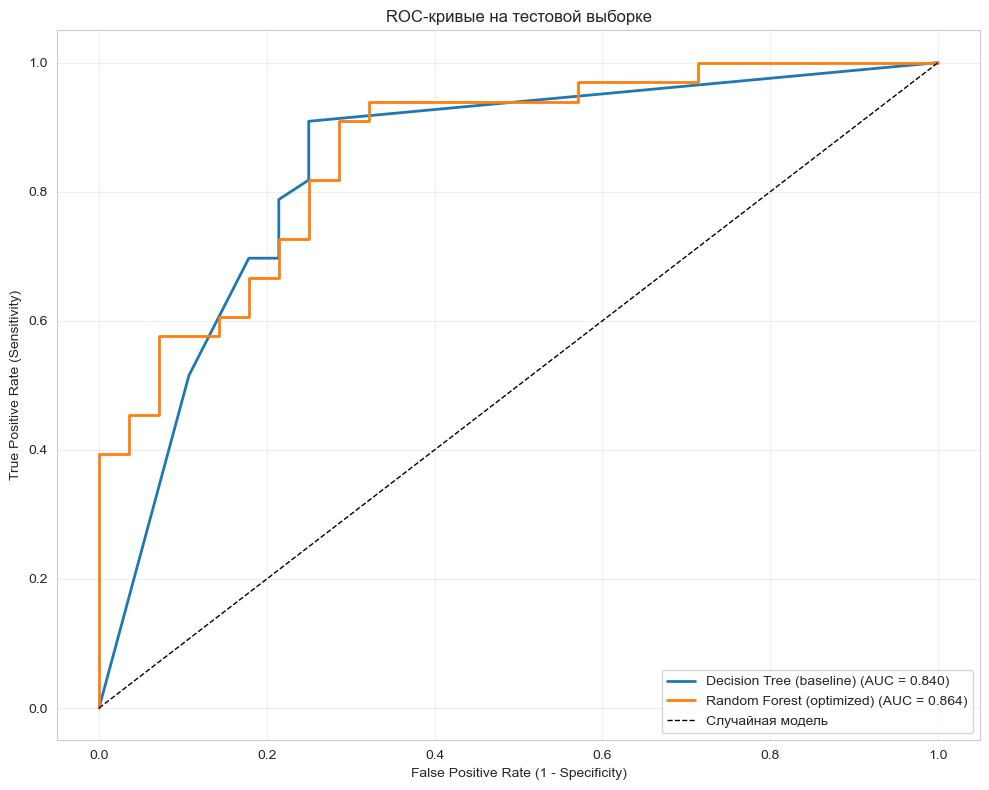

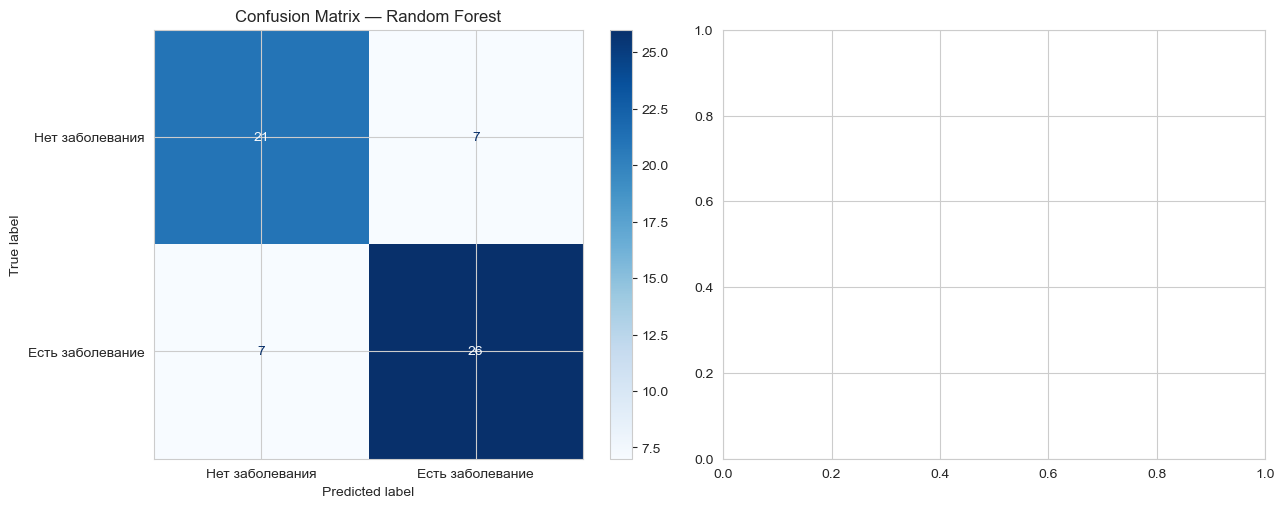

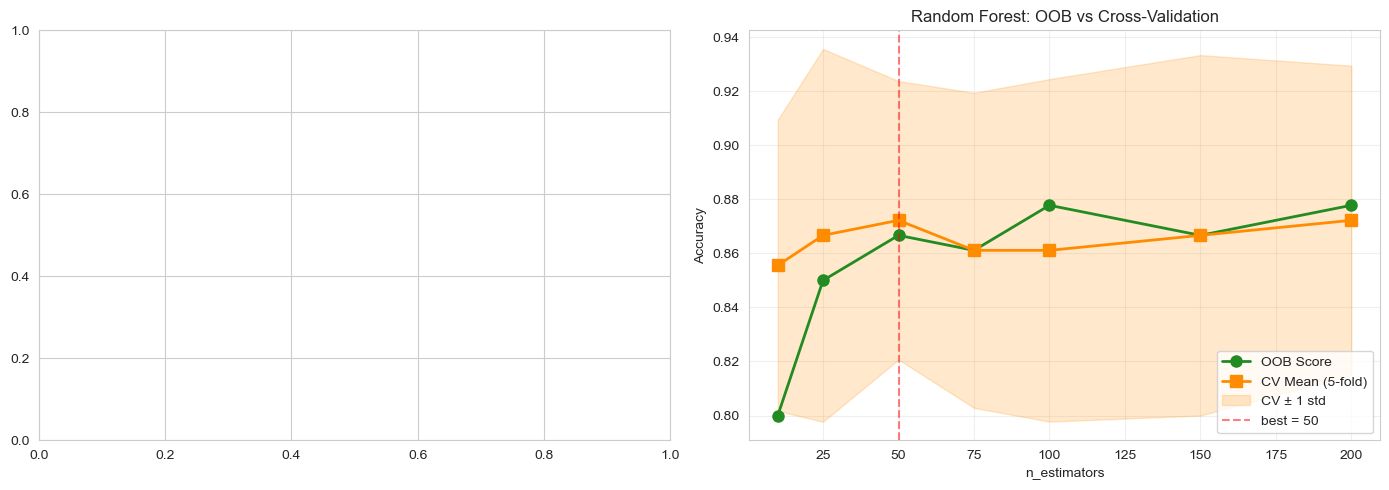

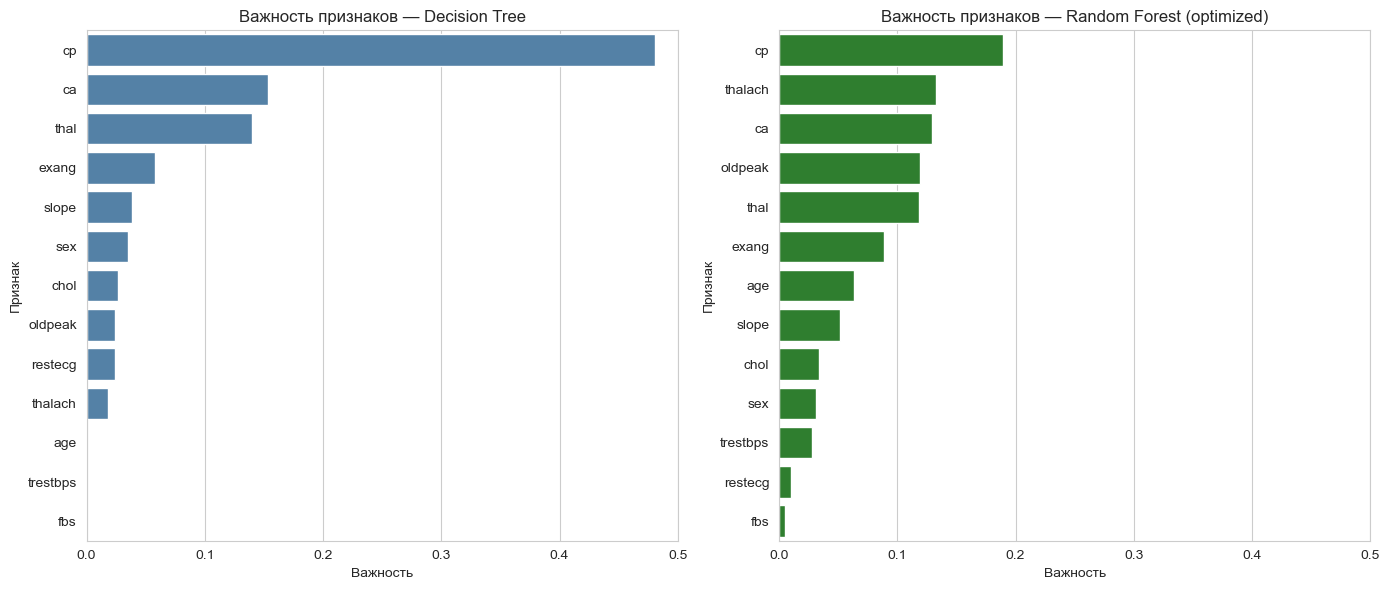

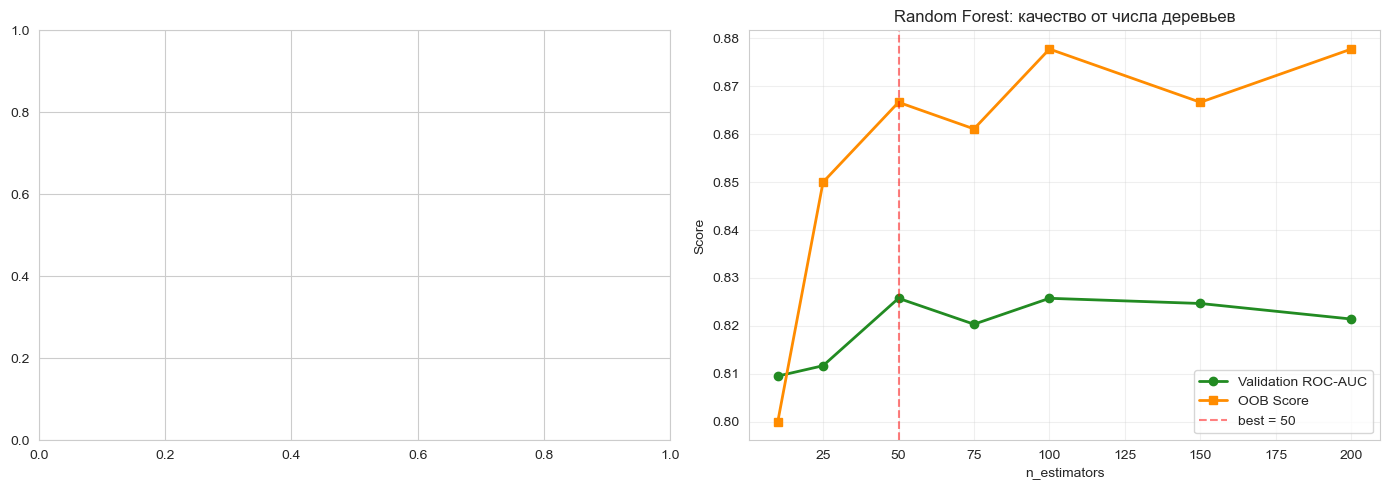

In [43]:
# ROC-кривые для всех моделей
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Случайная модель', linewidth=1)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC-кривые на тестовой выборке')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'week3_roc_curves.png', dpi=150, bbox_inches='tight')
print(f"ROC-кривые сохранены: {FIGURES_DIR / 'week3_roc_curves.png'}")

# Матрица ошибок
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, [('Random Forest', final_rf)]):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=['Нет заболевания', 'Есть заболевание'],
        cmap='Blues',
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'week3_confusion_matrices.png', dpi=150, bbox_inches='tight')
print(f"Матрицы ошибок сохранены: {FIGURES_DIR / 'week3_confusion_matrices.png'}")

# OOB vs CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[1].plot(
    n_estimators_range,
    rf_oob_cv,
    marker='o',
    label='OOB Score',
    color='forestgreen',
    linewidth=2,
    markersize=8
)
axes[1].plot(
    n_estimators_range,
    rf_cv_means,
    marker='s',
    label='CV Mean (5-fold)',
    color='darkorange',
    linewidth=2,
    markersize=8
)
axes[1].fill_between(
    n_estimators_range,
    np.array(rf_cv_means) - np.array(rf_cv_stds),
    np.array(rf_cv_means) + np.array(rf_cv_stds),
    alpha=0.2,
    color='darkorange',
    label='CV ± 1 std'
)
axes[1].axvline(x=best_rf_n, color='red', linestyle='--', alpha=0.5, label=f'best = {best_rf_n}')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Random Forest: OOB vs Cross-Validation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'week3_oob_vs_cv.png', dpi=150, bbox_inches='tight')
print(f"OOB vs CV сохранён: {FIGURES_DIR / 'week3_oob_vs_cv.png'}")

# Важность признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Decision Tree
tree_importance = pd.read_csv(MODELS_DIR / 'base_model_feature_importance.csv')
sns.barplot(
    data=tree_importance,
    x='Важность',
    y='Признак',
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Важность признаков — Decision Tree')
axes[0].set_xlim(0, 0.5)

# Random Forest
sns.barplot(
    data=feature_importance_rf,
    x='Важность',
    y='Признак',
    color='forestgreen',
    ax=axes[1]
)
axes[1].set_title('Важность признаков — Random Forest (optimized)')
axes[1].set_xlim(0, 0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'week3_importance_comparison.png', dpi=150, bbox_inches='tight')
print(f"Сравнение важности сохранено: {FIGURES_DIR / 'week3_importance_comparison.png'}")

# Графики качества от  числа деревьев для случайного леса
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[1].plot(
    n_estimators_range,
    rf_val_df['ROC-AUC'],
    marker='o',
    label='Validation ROC-AUC',
    color='forestgreen',
    linewidth=2
)
axes[1].plot(
    n_estimators_range,
    rf_val_df['OOB_Score'],
    marker='s',
    label='OOB Score',
    color='darkorange',
    linewidth=2
)
axes[1].axvline(x=best_rf_n, color='red', linestyle='--', alpha=0.5, label=f'best = {best_rf_n}')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Score')
axes[1].set_title('Random Forest: качество от числа деревьев')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'week3_quality_vs_estimators.png', dpi=150, bbox_inches='tight')
print(f"Графики качества сохранены: {FIGURES_DIR / 'week3_quality_vs_estimators.png'}")

plt.show()

# Сохранение моделей и результатов 

In [44]:
# Сохранение моделей
joblib.dump(final_rf, MODELS_DIR / 'random_forest_model.pkl')
joblib.dump(grid_rf, MODELS_DIR / 'random_forest_gridsearch.pkl')

# Сохранение метрик
test_comparison.to_csv(MODELS_DIR / 'week3_all_models_test_metrics.csv')
feature_importance_rf.to_csv(MODELS_DIR / 'random_forest_feature_importance.csv', index=False)

# Сохранение OOB vs CV результатов
rf_oob_cv_df.to_csv(MODELS_DIR / 'rf_oob_vs_cv.csv', index=False)